### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans, MeanShift
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm
import numpy as np
import plotly.express as px
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [2]:
data = pd.read_csv('data/marketing_campaign.csv', delimiter='\t')

In [3]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
data.shape

(2240, 29)

In [6]:
data.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [7]:
(data.isnull().mean() * 100).round(0)

ID                     0.0
Year_Birth             0.0
Education              0.0
Marital_Status         0.0
Income                 1.0
Kidhome                0.0
Teenhome               0.0
Dt_Customer            0.0
Recency                0.0
MntWines               0.0
MntFruits              0.0
MntMeatProducts        0.0
MntFishProducts        0.0
MntSweetProducts       0.0
MntGoldProds           0.0
NumDealsPurchases      0.0
NumWebPurchases        0.0
NumCatalogPurchases    0.0
NumStorePurchases      0.0
NumWebVisitsMonth      0.0
AcceptedCmp3           0.0
AcceptedCmp4           0.0
AcceptedCmp5           0.0
AcceptedCmp1           0.0
AcceptedCmp2           0.0
Complain               0.0
Z_CostContact          0.0
Z_Revenue              0.0
Response               0.0
dtype: float64

**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [8]:
data.Income.describe().round(2)

count      2216.00
mean      52247.25
std       25173.08
min        1730.00
25%       35303.00
50%       51381.50
75%       68522.00
max      666666.00
Name: Income, dtype: float64

In [9]:
data[data['Income'].isnull()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
10,1994,1983,Graduation,Married,NaN,1,0,15-11-2013,11,5,...,7,0,0,0,0,0,0,3,11,0
27,5255,1986,Graduation,Single,NaN,1,0,20-02-2013,19,5,...,1,0,0,0,0,0,0,3,11,0
43,7281,1959,PhD,Single,NaN,0,0,05-11-2013,80,81,...,2,0,0,0,0,0,0,3,11,0
48,7244,1951,Graduation,Single,NaN,2,1,01-01-2014,96,48,...,6,0,0,0,0,0,0,3,11,0
58,8557,1982,Graduation,Single,NaN,1,0,17-06-2013,57,11,...,6,0,0,0,0,0,0,3,11,0
71,10629,1973,2n Cycle,Married,NaN,1,0,14-09-2012,25,25,...,8,0,0,0,0,0,0,3,11,0
90,8996,1957,PhD,Married,NaN,2,1,19-11-2012,4,230,...,9,0,0,0,0,0,0,3,11,0
91,9235,1957,Graduation,Single,NaN,1,1,27-05-2014,45,7,...,7,0,0,0,0,0,0,3,11,0
92,5798,1973,Master,Together,NaN,0,0,23-11-2013,87,445,...,1,0,0,0,0,0,0,3,11,0
128,8268,1961,PhD,Married,NaN,0,1,11-07-2013,23,352,...,6,0,0,0,0,0,0,3,11,0


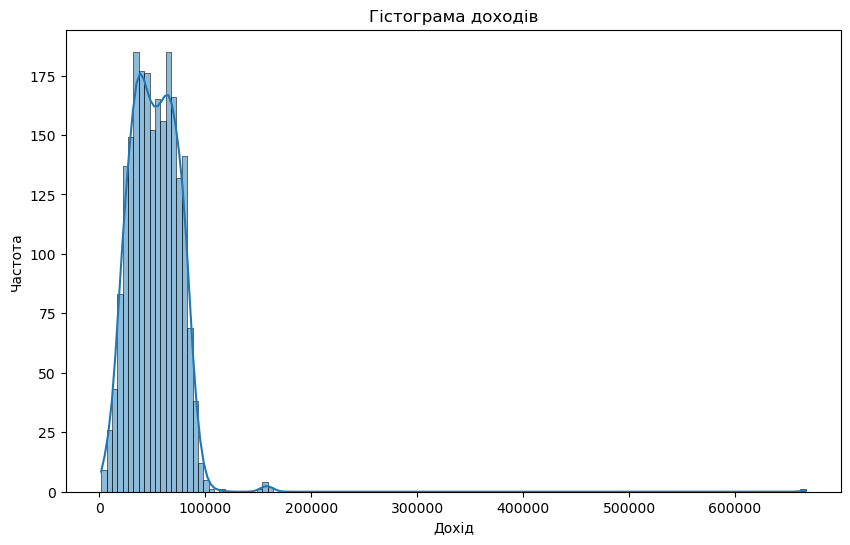

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(data['Income'], kde=True)
plt.title('Гістограма доходів')
plt.xlabel('Дохід')
plt.ylabel('Частота')
plt.show()

In [11]:
data['Income'].fillna(data['Income'].mean(), inplace=True)

**Аналіз:** Бачу, що середнє `52247.25` та медіана `51381.50` є близькми одне до одного. Також оскільки пропущених значень не багато, я вирішила подивитись на ці 24 рядки у яких є пропущенні значення більш детально і не помітила в них якихось спільних рис. Тому припускаю, що дані пропущені випадково, а не через якусь закономірність. З діаграми видно, що розподіл є несиметричний і має хвіст справа, але пропущених значень лише 1% - це не дуже повпливає на розподіл після заміщення.

**Рішення:** Я прийняла рішення заповнити відсутні значення середнім.

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

Спершу попрацюю з колонкою `Dt_Customer`. Я хочу перетворити цю колонку у кількість днів, яка дорівнюватиме тому скільки клієнт вже перебуває зареєстрованим.

In [12]:
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], format='%d-%m-%Y')
data['Days_Customer'] = (datetime.now() - data['Dt_Customer']).dt.days

In [13]:
# Видалення оригінальної колонки з датою
data.drop('Dt_Customer', axis=1, inplace=True)

In [14]:
data.Days_Customer.head()

0    4370
1    3820
2    4019
3    3846
4    3868
Name: Days_Customer, dtype: int64

Тепер обробка категоріальних змінних за допомогою One-Hot Encoding

In [15]:
data.select_dtypes(include=['object']).head()

,Education,Marital_Status
0,Graduation,Single
1,Graduation,Single
2,Graduation,Together
3,Graduation,Together
4,PhD,Married


In [16]:
cat_col = data.select_dtypes(include=['object']).columns.tolist()

In [17]:
# Ініціалізую OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

encoded_data = encoder.fit_transform(data[cat_col])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(cat_col))

data = pd.concat([data.drop(cat_col, axis=1), encoded_df], axis=1)

In [18]:
data.head()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,5524,1957,58138.0,0,0,58,635,88,546,172,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2174,1954,46344.0,1,1,38,11,1,6,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,4141,1965,71613.0,0,0,26,426,49,127,111,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,6182,1984,26646.0,1,0,26,11,4,20,10,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,5324,1981,58293.0,1,0,94,173,43,118,46,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [19]:
X = data
n_clusters = 3

# Ініціюємо кластеризатор
clusterer = KMeans(n_clusters=n_clusters, random_state=29, n_init='auto')
cluster_labels = clusterer.fit_predict(X)
silhouette_avg = silhouette_score(X, cluster_labels)
print(
    "Для n_clusters =",
    n_clusters,
    "Середнє значення silhouette_score становить:",
    silhouette_avg,
)

Для n_clusters = 3 Середнє значення silhouette_score становить: 0.5678350997959494


C:\Users\Anastasiia\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


In [20]:
# Розраховуємо метрику силуету для кожного екземпляра в наборі даних
sample_silhouette_values = silhouette_samples(X, cluster_labels)

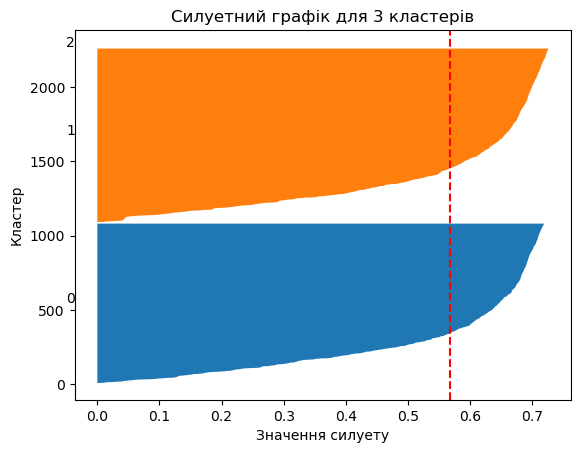

In [21]:
# Візуалізація метрики силуету
y_lower = 10
for i in range(n_clusters):
    # Сукупність значень силуету для всіх точок у кластері i
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    
    # Сортуємо значення
    ith_cluster_silhouette_values.sort()
    
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values)
    
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    
    y_lower = y_upper + 10  # 10 for the 0 samples

plt.title(f"Силуетний графік для {n_clusters} кластерів")
plt.xlabel("Значення силуету")
plt.ylabel("Кластер")

plt.axvline(x=silhouette_avg, color="red", linestyle="--")
plt.show()

In [22]:
# Перевірка кількості точок у кожному кластері
unique, counts = np.unique(cluster_labels, return_counts=True)
print(f"Кількість точок у кожному кластері: {dict(zip(unique, counts))}")

Кількість точок у кожному кластері: {0: 1072, 1: 1167, 2: 1}


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

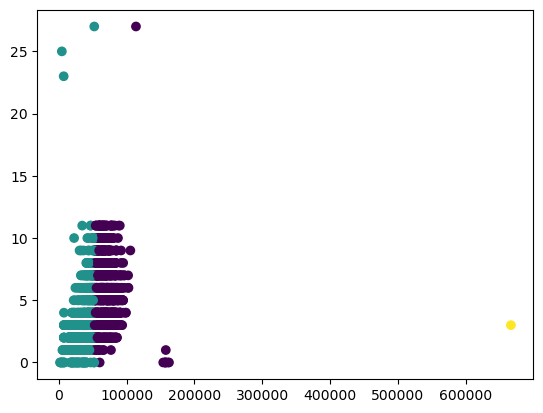

In [23]:
plt.scatter(X['Income'], X['NumWebPurchases'], c=cluster_labels)
plt.show()

In [24]:
fig = px.scatter_3d(X, 
                    x='Income', 
                    y='NumWebPurchases', 
                    z='MntWines', 
                    color=cluster_labels,
                    title="3D графік розсіювання кластерів")

# Показати графік
fig.show()

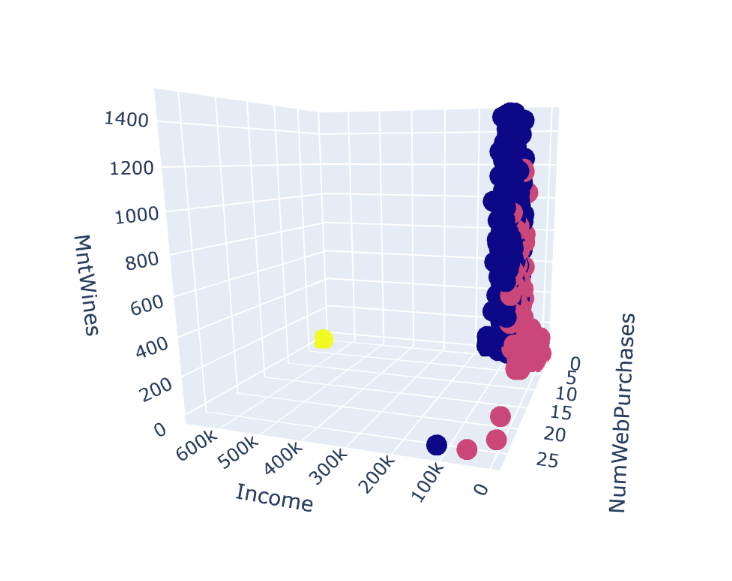

Залишу одну із осей `Income`. А для двох інших спробую зробити суми по усіх продуктах та по усіх взаємодіях. 

In [25]:
# Створення нової колонки 'Total_Products' як сума усіх витрат на продукти
data['Total_Products'] = data[['MntWines', 
                               'MntFruits', 
                               'MntMeatProducts', 
                               'MntFishProducts', 
                               'MntSweetProducts', 
                               'MntGoldProds']].sum(axis=1)

# Створення нової колонки 'Total_Interactions' як сума усіх взаємодій
data['Total_Interactions'] = data[['NumWebPurchases', 
                                   'NumCatalogPurchases', 
                                   'NumStorePurchases', 
                                   'NumWebVisitsMonth']].sum(axis=1)

# Перегляд результату
print(data[['Total_Products', 'Total_Interactions']].head())

   Total_Products  Total_Interactions
0            1617                  29
1              27                   9
2             776                  24
3              53                  12
4             422                  19


In [26]:
fig = px.scatter_3d(X, 
                    x='Income', 
                    y='Total_Products', 
                    z='Total_Interactions', 
                    color=cluster_labels,
                    title="3D графік розсіювання кластерів")

# Показати графік
fig.show()

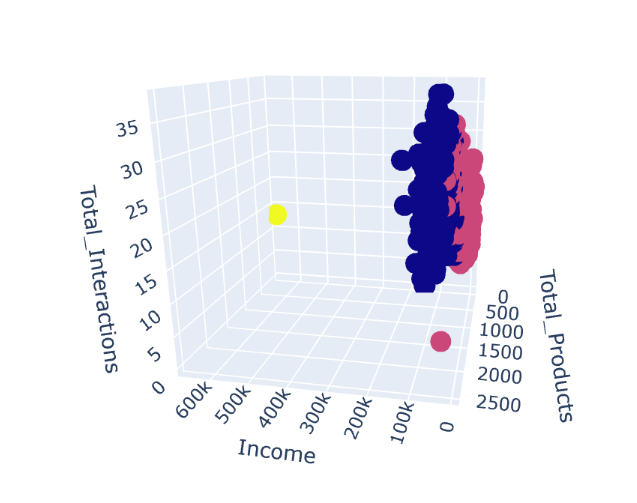

Бачу що є один викид. Хочу прибрати його на візуалізації, щоб було краще видно розподіл між двома іншими кластерами.

In [27]:
# Побудова графіка з фільтрованими даними
fig = px.scatter_3d(data[data['Income'] < 500000], 
                    x='Income', 
                    y='Total_Products', 
                    z='Total_Interactions', 
                    color=cluster_labels[data[data['Income'] < 500000].index],
                    title="3D графік розсіювання кластерів")

fig.show()

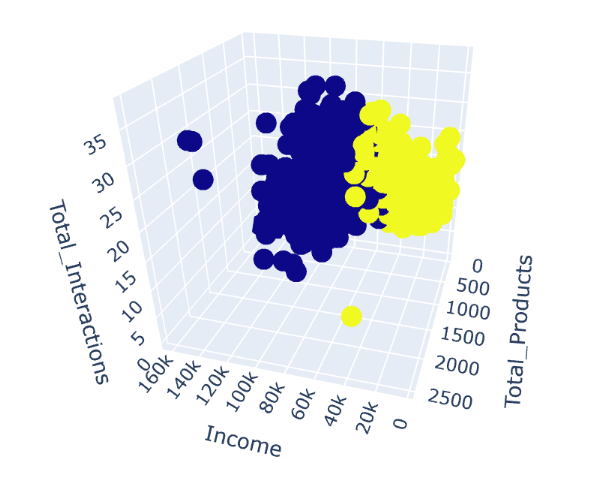

**Спостереження:** Один із кластерів містить викид. Два інших візуально виглядають так, наче мають сенс. В основному поділ відбувся за значенням доходу. До одного кластеру віднеслись клієнти з рівнем доходу юільшим приблизно `49000`, до іншого відповідно всі решта.

**Завдання 6**. Масштабуйте дані і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [28]:
cols_to_scale = ['Year_Birth', 
                 'Income', 
                 'Recency', 
                 'MntWines', 
                 'MntFruits', 
                 'MntMeatProducts', 
                 'MntFishProducts', 
                 'MntSweetProducts', 
                 'MntGoldProds', 
                 'NumDealsPurchases', 
                 'Total_Products', 
                 'Total_Interactions']

In [29]:
data.set_index('ID', inplace=True)

In [30]:
# Створення копії DataFrame до масштабування
data_original = data.copy()

In [31]:
# Ініціалізація StandardScaler
scaler = StandardScaler()

# Масштабування даних
data[cols_to_scale] = scaler.fit_transform(data[cols_to_scale])

data[cols_to_scale]

,Year_Birth,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,Total_Products,Total_Interactions
ID,,,,,,,,,,,,
5524,-0.985345,0.235327,0.307039,0.983781,1.551577,1.679702,2.462147,1.476500,0.843207,0.349414,1.679417,1.701865
2174,-1.235733,-0.235826,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,-0.631503,-0.729006,-0.168236,-0.961275,-1.351786
4141,-0.317643,0.773633,-0.798086,0.362723,0.570804,-0.177032,1.345274,-0.146905,-0.038766,-0.685887,0.282673,0.938453
6182,1.268149,-1.022732,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,-0.583043,-0.748179,-0.168236,-0.918094,-0.893738
5324,1.017761,0.241519,1.550305,-0.389085,0.419916,-0.216914,0.155164,-0.001525,-0.556446,1.384715,-0.305254,0.175040
...,...,...,...,...,...,...,...,...,...,...,...,...
10870,-0.150717,0.358568,-0.107383,1.203678,0.419916,0.066692,0.081926,2.203398,3.891766,-0.168236,1.221032,0.480405
4001,-1.903435,0.470064,0.237969,0.303291,-0.661449,-0.606873,-0.687068,-0.655733,-0.690659,2.420015,-0.268717,0.633087
7270,1.017761,0.189106,1.446700,1.795020,0.545656,0.221789,-0.101168,-0.364974,-0.383886,-0.685887,1.054951,0.938453


In [32]:
X = data

clusterer = KMeans(n_clusters=n_clusters, random_state=29, n_init='auto')
cluster_labels = clusterer.fit_predict(X)
silhouette_avg = silhouette_score(X, cluster_labels)

print(
    "Для n_clusters =",
    n_clusters,
    "Середнє значення silhouette_score становить:",
    silhouette_avg.round(2),
)

Для n_clusters = 3 Середнє значення silhouette_score становить: 0.58


C:\Users\Anastasiia\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.



In [33]:
# Розраховуємо метрику силуету для кожного екземпляра в наборі даних
sample_silhouette_values = silhouette_samples(X, cluster_labels)

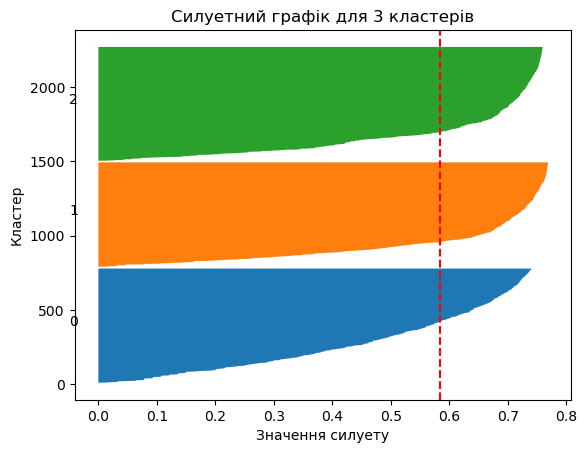

In [34]:
# Візуалізація метрики силуету
y_lower = 10
for i in range(n_clusters):
    # Сукупність значень силуету для всіх точок у кластері i
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    
    # Сортуємо значення
    ith_cluster_silhouette_values.sort()
    
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values)
    
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    
    y_lower = y_upper + 10  # 10 for the 0 samples

plt.title(f"Силуетний графік для {n_clusters} кластерів")
plt.xlabel("Значення силуету")
plt.ylabel("Кластер")

plt.axvline(x=silhouette_avg, color="red", linestyle="--")
plt.show()

In [35]:
# Перевірка кількості точок у кожному кластері
unique, counts = np.unique(cluster_labels, return_counts=True)
print(f"Кількість точок у кожному кластері: {dict(zip(unique, counts))}")

Кількість точок у кожному кластері: {0: 770, 1: 704, 2: 766}


In [36]:
fig = px.scatter_3d(X, 
                    x='Income', 
                    y='Total_Products', 
                    z='Total_Interactions', 
                    color=cluster_labels,
                    title="3D графік розсіювання кластерів")

# Показати графік
fig.show()

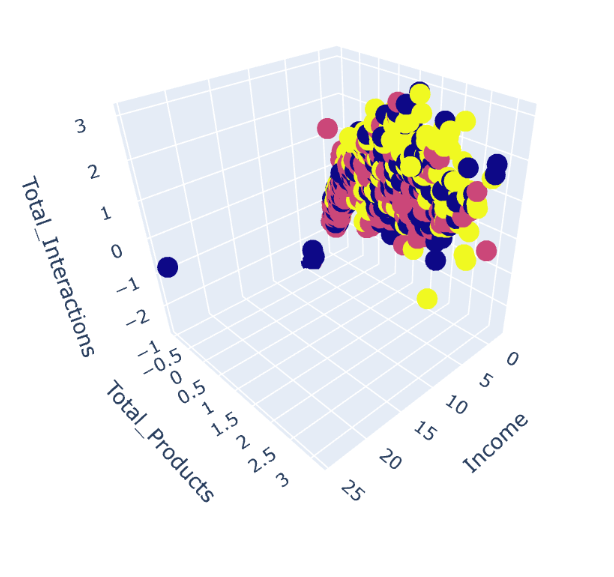

**Спостереження:** Середнє значення silhouette_score становить: `0.58`. В порівнянні із попереднім `0.57` метрика покращилась. Також розподіл даних на кластери більш рівномірний. Тепер орієнтовно однакова к-сть точок у кожному кластері. Проте на візуалізації це виглядає досить рандомно. Варто спробувати підібрати інші характеристики для візуалізації.

In [37]:
# Побудова графіка
fig = px.scatter_3d(X[X['Income'] < 20], 
                    x='Income', 
                    y='Total_Products', 
                    z='Days_Customer', 
                    color=cluster_labels[X['Income'] < 20],
                    title="3D графік розсіювання кластерів")

# Показати графік
fig.show()

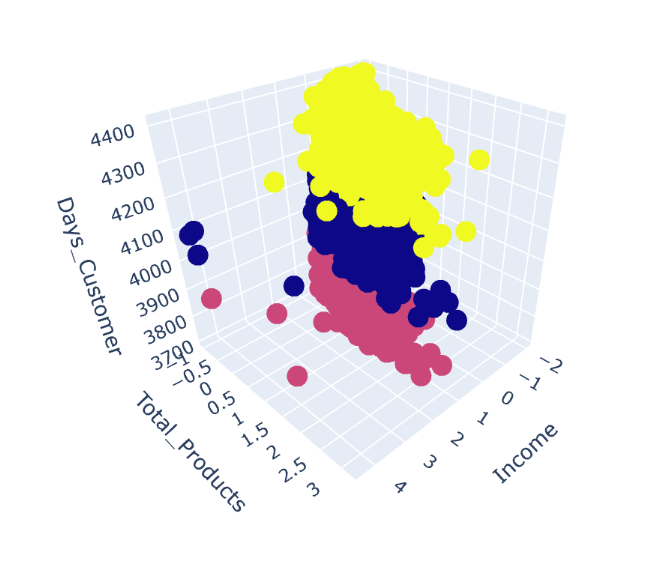

**Спостереження:** Тепер поділ відбувся за параметром `Days_Customer`.

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [38]:
# Створюю маску для видалення викидів
mask = (data['Income'] < data['Income'].quantile(0.99)) & (data['NumWebPurchases'] < data['NumWebPurchases'].quantile(0.99))

# Видалення викидів на основі квантилів для 'Income' і 'NumWebPurchases'
data_99 = data[mask]

# Видалення відповідних кластерних міток
filtered_cluster_labels = cluster_labels[mask]

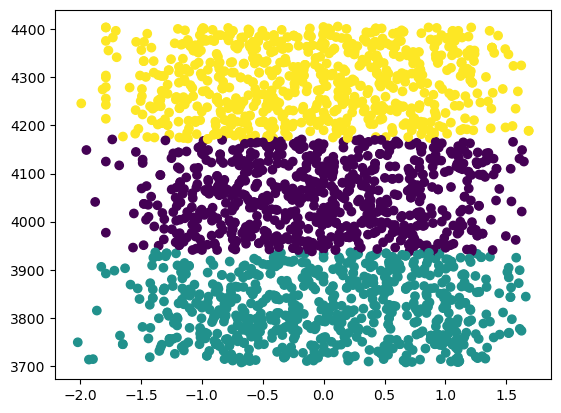

In [39]:
# Виведення графіка для перевірки видалення викидів
plt.scatter(data_99['Income'], data_99['Days_Customer'], c=filtered_cluster_labels)
plt.show()

In [40]:
# Побудова графіка
fig = px.scatter_3d(data_99, 
                    x='Income', 
                    y='Total_Products', 
                    z='Days_Customer', 
                    color=filtered_cluster_labels,
                    title="3D графік розсіювання кластерів")

# Показати графік
fig.show()

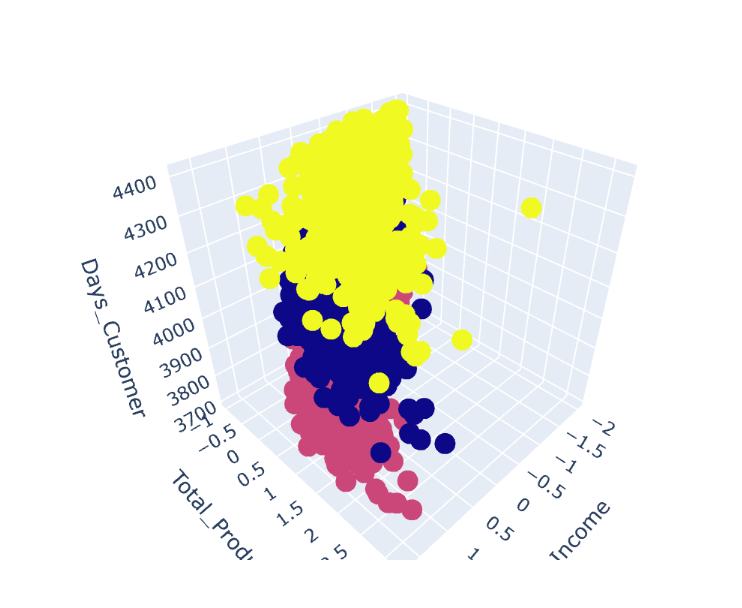

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

C:\Users\Anastasiia\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.

C:\Users\Anastasiia\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.

C:\Users\Anastasiia\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.

C:\Users\Anastasiia\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there a

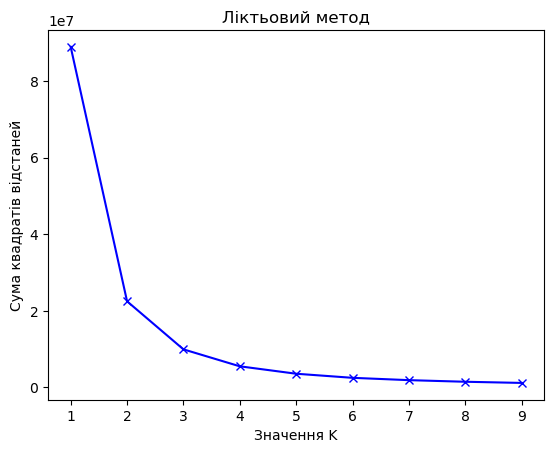

In [41]:
X = data_99

K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto').fit(X)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('Значення K')
plt.ylabel('Сума квадратів відстаней')
plt.title('Ліктьовий метод')
plt.show()

In [42]:
n_clusters = 3

clusterer = KMeans(n_clusters=n_clusters, random_state=29, n_init='auto')
cluster_labels = clusterer.fit_predict(X)
silhouette_avg = silhouette_score(X, filtered_cluster_labels)

print(
    "Для n_clusters =",
    n_clusters,
    "Середнє значення silhouette_score становить:",
    silhouette_avg.round(2),
)

Для n_clusters = 3 Середнє значення silhouette_score становить: 0.59


C:\Users\Anastasiia\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.



In [43]:
# Побудова графіка
fig = px.scatter_3d(X, 
                    x='Income', 
                    y='Total_Products', 
                    z='Days_Customer', 
                    color=filtered_cluster_labels,
                    title="3D графік розсіювання кластерів")

# Показати графік
fig.show()

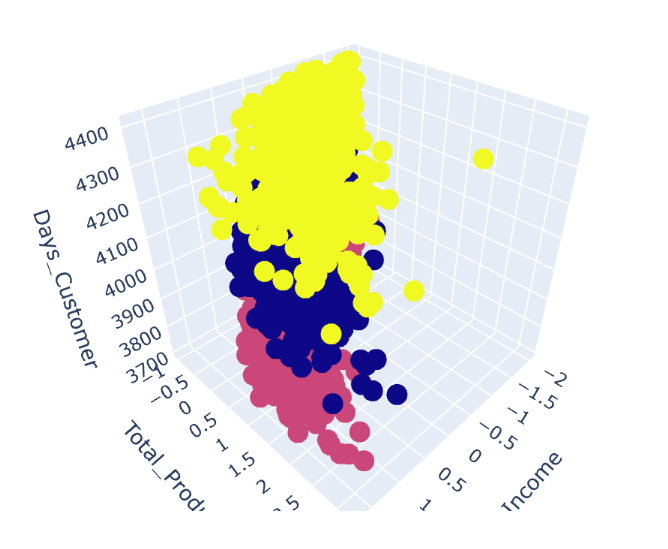

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

In [52]:
X = data_original[mask]

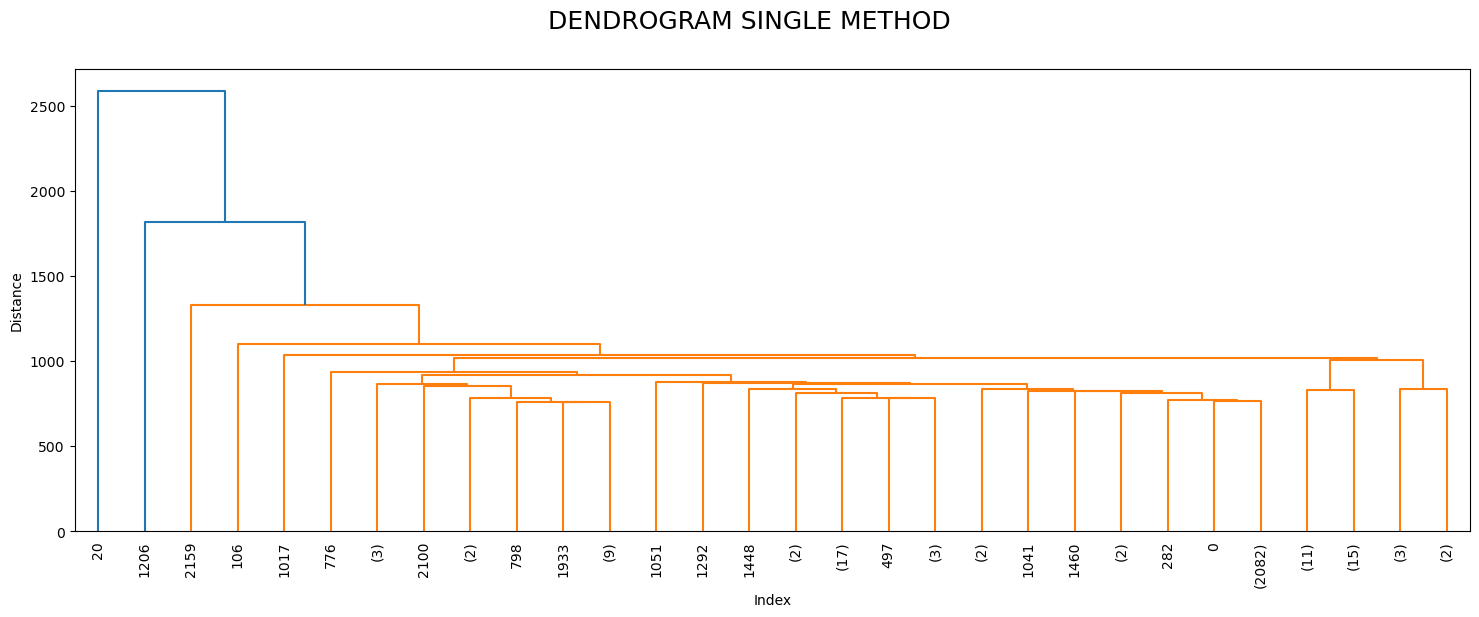

In [55]:
dist_sin = linkage(X, method="single")
plt.figure(figsize=(18,6))
dendrogram(dist_sin, leaf_rotation=90, truncate_mode='lastp')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("DENDROGRAM SINGLE METHOD",fontsize=18)
plt.show()

**Спостереження:** На великій висоті видно два основних злиття. З аналізу дендограми оптимальною буде її обрізка на висоті між значеннями `2000` і `2500`. 

In [59]:
X['2_clust'] = fcluster(dist_sin, 2, criterion='maxclust')
X['3_clust'] = fcluster(dist_sin, 3, criterion='maxclust')

C:\Users\Anastasiia\AppData\Local\Temp\ipykernel_11760\3258152258.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Anastasiia\AppData\Local\Temp\ipykernel_11760\3258152258.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [60]:
# Метрика силуету для двох кластерів
silhouette_avg_2 = silhouette_score(X, X['2_clust'])
print(f"Середнє значення silhouette_score для 2 кластерів становить: {silhouette_avg_2}")

# Метрика силуету для трьох кластерів
silhouette_avg_3 = silhouette_score(X, X['3_clust'])
print(f"Середнє значення silhouette_score для 3 кластерів становить: {silhouette_avg_3}")

Середнє значення silhouette_score для 2 кластерів становить: 0.42253179563381915
Середнє значення silhouette_score для 3 кластерів становить: 0.42316312304115383


**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте метрику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

In [67]:
X = data[mask]

In [69]:
# Масив значень bandwidth для тестування
bandwidth_values = [0.5, 1.0, 2.0, 4.0]

# Зберігання результатів
results = []

In [71]:
for bandwidth in bandwidth_values:
    meanshift = MeanShift(bandwidth=bandwidth)
    
    meanshift_labels = meanshift.fit_predict(X)
    
    silhouette_avg = silhouette_score(X, meanshift_labels)
    
    # Зберігаємо результати
    results.append((bandwidth, silhouette_avg, len(set(meanshift_labels))))
    print(f"bandwidth: {bandwidth}, silhouette score: {silhouette_avg}, clusters: {len(set(meanshift_labels))}")

# Виводимо результати для всіх значень bandwidth
for result in results:
    print(f"bandwidth: {result[0]}, silhouette score: {result[1]}, number of clusters: {result[2]}")

bandwidth: 0.5, silhouette score: 0.16311495570365972, clusters: 1990
bandwidth: 1.0, silhouette score: 0.17723508719798728, clusters: 1968
bandwidth: 2.0, silhouette score: 0.18095024541024954, clusters: 1955
bandwidth: 4.0, silhouette score: 0.18997088685387628, clusters: 1258
bandwidth: 0.5, silhouette score: 0.16311495570365972, number of clusters: 1990
bandwidth: 1.0, silhouette score: 0.17723508719798728, number of clusters: 1968
bandwidth: 2.0, silhouette score: 0.18095024541024954, number of clusters: 1955
bandwidth: 4.0, silhouette score: 0.18997088685387628, number of clusters: 1258


Занадто малі підібрані значення для `bandwidth` в результаті чого алгоритм ділить дані на дуже велику к-сть кластерів.

In [73]:
# Масив значень bandwidth для тестування
bandwidth_values = [5.0, 7.0, 10.0, 15.0]

# Зберігання результатів
results = []

for bandwidth in bandwidth_values:
    meanshift = MeanShift(bandwidth=bandwidth, bin_seeding=True)
    
    meanshift_labels = meanshift.fit_predict(X)
    
    silhouette_avg = silhouette_score(X, meanshift_labels)
    
    # Зберігаємо результати
    results.append((bandwidth, silhouette_avg, len(set(meanshift_labels))))
    print(f"bandwidth: {bandwidth}, silhouette score: {silhouette_avg}, clusters: {len(set(meanshift_labels))}")

bandwidth: 5.0, silhouette score: 0.1994962313087498, clusters: 286
bandwidth: 7.0, silhouette score: 0.22943757768610468, clusters: 112
bandwidth: 10.0, silhouette score: 0.28473251726768567, clusters: 53
bandwidth: 15.0, silhouette score: 0.38364739765977857, clusters: 29


In [75]:
# Масив значень bandwidth для тестування
bandwidth_values = [35.0, 40.0, 50.0, 60.0]

# Зберігання результатів
results = []

for bandwidth in bandwidth_values:
    meanshift = MeanShift(bandwidth=bandwidth, bin_seeding=True)
    
    meanshift_labels = meanshift.fit_predict(X)
    
    silhouette_avg = silhouette_score(X, meanshift_labels)
    
    # Зберігаємо результати
    results.append((bandwidth, silhouette_avg, len(set(meanshift_labels))))
    print(f"bandwidth: {bandwidth}, silhouette score: {silhouette_avg}, clusters: {len(set(meanshift_labels))}")

bandwidth: 35.0, silhouette score: 0.4886595784248319, clusters: 9
bandwidth: 40.0, silhouette score: 0.521952865820888, clusters: 8
bandwidth: 50.0, silhouette score: 0.5282648836619726, clusters: 7
bandwidth: 60.0, silhouette score: 0.5544181852576483, clusters: 5


In [77]:
# Масив значень bandwidth для тестування
bandwidth_values = [80.0, 100.0, 125.0, 150.0]

# Зберігання результатів
results = []

for bandwidth in bandwidth_values:
    meanshift = MeanShift(bandwidth=bandwidth, bin_seeding=True)
    
    meanshift_labels = meanshift.fit_predict(X)
    
    silhouette_avg = silhouette_score(X, meanshift_labels)
    
    # Зберігаємо результати
    results.append((bandwidth, silhouette_avg, len(set(meanshift_labels))))
    print(f"bandwidth: {bandwidth}, silhouette score: {silhouette_avg}, clusters: {len(set(meanshift_labels))}")

bandwidth: 80.0, silhouette score: 0.5609996639952246, clusters: 4
bandwidth: 100.0, silhouette score: 0.5665149442118506, clusters: 4
bandwidth: 125.0, silhouette score: 0.5762835146096764, clusters: 3
bandwidth: 150.0, silhouette score: 0.621278469655733, clusters: 2


In [78]:
# Виконання кластеризації з обраним параметром bandwidth = 150
meanshift = MeanShift(bandwidth=150.0, bin_seeding=True)

# Отримання кластерних міток
meanshift_labels = meanshift.fit_predict(X)

In [79]:
# Побудова графіка 3D розсіювання
fig = px.scatter_3d(X, 
                    x='Income', 
                    y='Total_Products', 
                    z='Days_Customer', 
                    color=meanshift_labels,
                    title="3D графік розсіювання кластерів з bandwidth=150")

# Показати графік
fig.show()

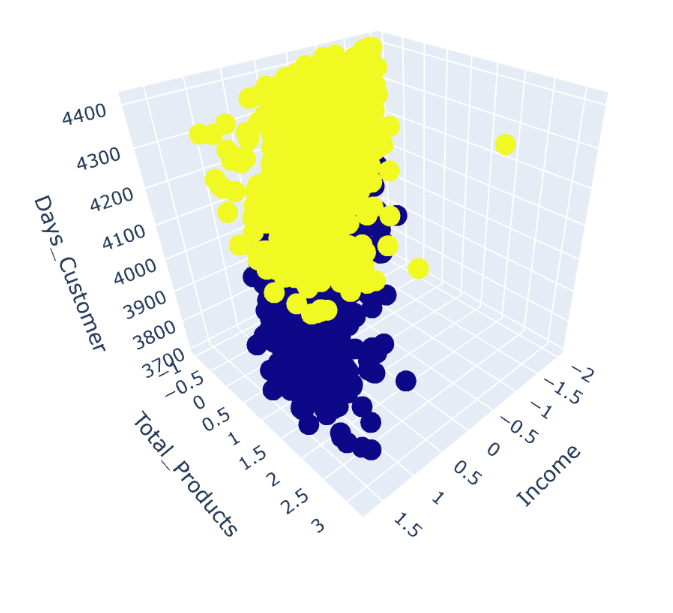

**Висновок:** MeanShift на відмасштабованих даних без викидів показав найвищий показник silhouette score: `0.62` при поділі на 2 кластери. Тому ця кластеризація могла б бути корисною.